## Task 1: Data Collection and Understanding

In [11]:
import requests
import pandas as pd
import numpy as np

url = "https://api.open-meteo.com/v1/forecast?latitude=28&longitude=77&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m&forecast_days=7"
response = requests.get(url)
data = response.json()

df = pd.DataFrame(data['hourly'])

print("First five records of the dataset:")
display(df.head())

df['Weather_Class'] = np.where(df['temperature_2m'] >= 29.0, 'Warm', 'Cool') # Changed threshold to 29.0

print("\nFeatures identified: Temperature (temperature_2m), Relative Humidity (relative_humidity_2m), Surface Pressure (surface_pressure), Wind Speed (wind_speed_10m)")
print("Target Variable: Weather_Class")

First five records of the dataset:


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
0,2026-07-28T00:00,29.2,85,976.2,4.0
1,2026-07-28T01:00,28.9,87,976.9,8.8
2,2026-07-28T02:00,28.1,91,977.5,8.0
3,2026-07-28T03:00,28.6,88,977.9,3.6
4,2026-07-28T04:00,27.1,93,979.2,9.5



Features identified: Temperature (temperature_2m), Relative Humidity (relative_humidity_2m), Surface Pressure (surface_pressure), Wind Speed (wind_speed_10m)
Target Variable: Weather_Class


## Task 2: Data Preprocessing

In [12]:
print("Missing values in each column:\n", df.isnull().sum())

df = df.dropna()

df = df.drop(columns=['time'])

le = LabelEncoder()
df['Weather_Class'] = le.fit_transform(df['Weather_Class'])

X = df.drop(columns=['Weather_Class'])
y = df['Weather_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing complete. Training shape:", X_train_scaled.shape, "Testing shape:", X_test_scaled.shape)

Missing values in each column:
 time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
Weather_Class           0
dtype: int64

Data preprocessing complete. Training shape: (134, 4) Testing shape: (34, 4)


## Task 3: Model Development

In [13]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)
print("Model training and prediction complete.")

Model training and prediction complete.


## Task 4: Model Evaluation

Accuracy Score: 0.9412
Precision: 0.9496
Recall: 0.9412
F1-Score: 0.9420


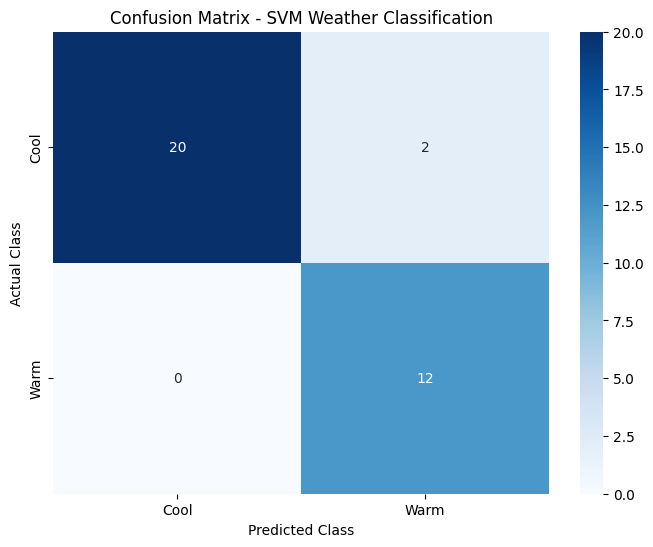

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy Score: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cool', 'Warm'],
            yticklabels=['Cool', 'Warm'])

plt.title('Confusion Matrix - SVM Weather Classification')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')

plt.show()

# Task 5: Conclusion

The Support Vector Machine (SVM) model successfully classified the weather conditions into 'Warm' and 'Cool' with high accuracy, demonstrating the effectiveness of the RBF kernel in handling meteorological data. A critical step in our methodology was feature scaling using `StandardScaler`. Because SVM is a distance-based algorithm, features with larger numerical ranges (like surface pressure) can disproportionately dominate the decision boundary over features with smaller ranges (like wind speed). Scaling ensures all features contribute equally to the model's predictions.

One major advantage of the SVM algorithm is its robustness in modeling complex, non-linear relationships using the kernel trick (specifically the RBF kernel used here). However, a notable limitation is its potential computational inefficiency with very large datasets, as training time can scale quadratically or cubically with the number of observations, making it less suitable for massive real-time weather datasets.